In [61]:
# If you are running in a fresh environment, uncomment to install dependencies:
# !pip -q install torch torchvision matplotlib tqdm scikit-learn

import os
import random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import models

print("torch:", torch.__version__)
device = "cuda"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

torch: 2.10.0+cu130
device: cuda


## 1. Dataset and DataLoader

In [62]:
# Q1: Build the data pipeline
data_dir = "./data/train"
batch_size = 128  # Use 128 for training
num_workers = 8  # For fully reproducible ordering across platforms
train_val_split = 0.8

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=train_tf)

full_dataset.class_to_idx = {str(i): i for i in range(100)}
full_dataset.classes = [str(i) for i in range(100)]

total_size = len(full_dataset)
train_size = int(train_val_split * total_size)
val_size = total_size - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_set, shuffle=True, batch_size=batch_size, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(dataset=val_set, shuffle=False, batch_size=batch_size, num_workers=num_workers, pin_memory=True)


print("train/val/test:", len(train_set), len(val_set))

train/val/test: 863 216


## 2. Define the CNN Model

In [67]:
model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_feat = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_feat, 100)

model = model.to(device)
print(model)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

## 3. Training Loop

### 3.1 Training Function

In [68]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier[1].parameters(), lr=1e-3)

scaler = torch.amp.GradScaler(device)

def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    total_accuracy = 0
    total_count = 0

    for inputs, labels in loader:

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item() * inputs.size(0)
        
        _, preds = torch.max(outputs, 1)
        total_accuracy += (preds == labels).sum().item()
        total_count += labels.size(0)
        
    avg_loss = total_loss / total_count
    accuracy = total_accuracy / total_count
    
    return avg_loss, accuracy
    
    # ========== YOUR CODE ENDS HERE ============

### 3.2 Validation Function

In [69]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy

    model.eval()

    total_loss = 0
    total_accuracy = 0
    total_count = 0

    for inputs, labels in loader:

        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        total_loss += loss.item() * inputs.size(0)
        
        _, preds = torch.max(outputs, 1)
        total_accuracy += (preds == labels).sum().item()
        total_count += labels.size(0)
        
    avg_loss = total_loss / total_count
    accuracy = total_accuracy / total_count
    
    return avg_loss, accuracy
    
    # ========== YOUR CODE ENDS HERE ============

### 3.3 Training Loop

In [70]:
# Q3.3: Training loop with checkpointing
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_final_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Loop through epochs
# - Each epoch: train, validate, log metrics
# - Track best validation accuracy and save checkpoint when improved
# - Print training and validation metrics each epoch
# - For checkpoint: save a dictionary containing keys `model_state_dict` and `epoch`
import time

start_time = time.perf_counter()


for epoch in range(epochs):
    epoch_start = time.perf_counter()
    
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
              f"Time for epoch: {time.perf_counter() - epoch_start:.2f} sec, Time Elapsed: {time.perf_counter() - start_time:.2f} sec")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": best_epoch
        }, ckpt_path)

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch [1/10] | Train Loss: 4.4048, Train Acc: 0.0579 | Val Loss: 4.1943, Val Acc: 0.1157 | Time for epoch: 19.56 sec, Time Elapsed: 19.56 sec
Epoch [2/10] | Train Loss: 3.7049, Train Acc: 0.2457 | Val Loss: 3.7311, Val Acc: 0.1898 | Time for epoch: 18.72 sec, Time Elapsed: 38.43 sec
Epoch [3/10] | Train Loss: 3.1804, Train Acc: 0.3650 | Val Loss: 3.3139, Val Acc: 0.2315 | Time for epoch: 18.81 sec, Time Elapsed: 57.39 sec
Epoch [4/10] | Train Loss: 2.7978, Train Acc: 0.4426 | Val Loss: 3.0760, Val Acc: 0.2870 | Time for epoch: 18.68 sec, Time Elapsed: 76.21 sec
Epoch [5/10] | Train Loss: 2.4901, Train Acc: 0.5365 | Val Loss: 2.9088, Val Acc: 0.2731 | Time for epoch: 17.83 sec, Time Elapsed: 94.19 sec
Epoch [6/10] | Train Loss: 2.2345, Train Acc: 0.6072 | Val Loss: 2.7388, Val Acc: 0.2963 | Time for epoch: 19.21 sec, Time Elapsed: 113.40 sec
Epoch [7/10] | Train Loss: 2.0281, Train Acc: 0.6512 | Val Loss: 2.6309, Val Acc: 0.3472 | Time for epoch: 19.92 sec, Time Elapsed: 133.47 sec
Epoc

### 3.4 Plot Training Curves

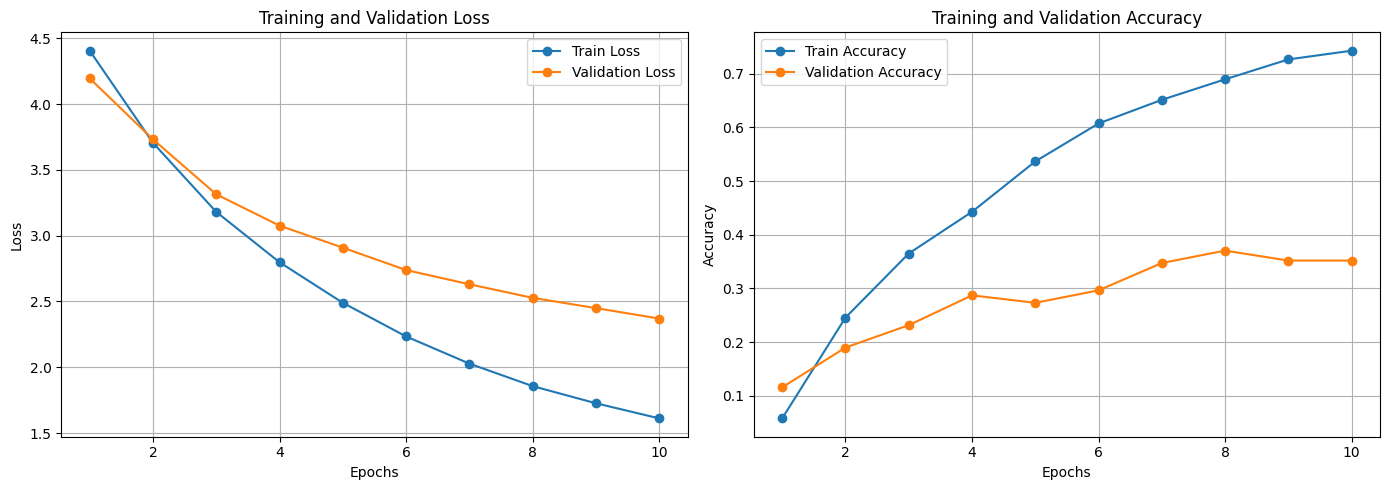

In [71]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

epochs_range = range(1, epochs + 1)
    
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label='Train Loss', marker='o')
plt.plot(epochs_range, history["val_loss"], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label='Train Accuracy', marker='o')
plt.plot(epochs_range, history["val_acc"], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ========== YOUR CODE ENDS HERE ============

## 4. Testing

In [72]:
class UnlabeledTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, img_name

test_dir = "./data/test"
test_dataset = UnlabeledTestDataset(test_dir=test_dir, transform=val_tf)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

predictions = []

print("Generating predictions for submission...")
with torch.no_grad():
    for images, img_ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        for img_id, pred in zip(img_ids, preds):
            predictions.append({"ID": img_id, "Label": pred.item()})

submission_df = pd.DataFrame(predictions)
submission_df.to_csv("submission.csv", index=False)
print("Saved submission.csv successfully!")

Generating predictions for submission...
Saved submission.csv successfully!
